# Objective

The objective of this analysis is to evaluate annual inventory health (for the year 2024) across key operational dimensions: inventory efficiency, demand alignment, capital allocation, and movement dynamics in order to:

- Analyze inventory efficiency trends using turnover, days of inventory (DOI), and inactive inventory percentage to understand stock utilization over time
- Examine alignment between inventory investment and demand to assess how effectively inventory supports revenue generation
- Evaluate the concentration of inventory across SKUs to identify dependency on a limited set of products/vendors.
- Assess stability of inventory levels using variability measures (CV) to understand consistency in stock holding patterns
- Analyze distribution of inventory capital across GMROI segments to evaluate quality of capital allocation
- Examine inventory movement segmentation (fast, moderate, slow) to understand how inventory is distributed in terms of revenue contribution and capital lock in

This enables a structured understanding of how inventory is performing across efficiency, balance, and capital allocation dimensions, supporting improved visibility into overall inventory health.

### Importing libraries

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sqlalchemy import create_engine,text
from sqlalchemy.engine import URL
import os
from dotenv import load_dotenv

### Connection setup and Reading required datasets

In [2]:
# load env file and import credentials
load_dotenv()
DB_USER = os.getenv("DB_USER")
DB_HOST = os.getenv("DB_HOST")
DB_PASSWORD = os.getenv("DB_PASSWORD")

# establish connection to the 'inventory_db' database
conn_url = URL.create (
    drivername = "mysql+pymysql",
    host = DB_HOST,
    username = DB_USER,
    password = DB_PASSWORD,
    database = 'inventory_db'
)
conn_eng = create_engine(conn_url)
print("Connection Open to 'inventory_db' database")

Connection Open to 'inventory_db' database


In [3]:
#  reading required datasets for the analysis
with conn_eng.connect() as conn:
    dataset = pd.read_sql(text("select * from product_summary;"),conn)
    inv_snapshot = pd.read_sql(text("select * from product_monthly_inventory;"),conn)

### Data Preparation

In [4]:
# assign date column appropriate data type 
inv_snapshot['month_startdate'] = pd.to_datetime(inv_snapshot['month_startdate'])

# data enrichment
inv_snapshot = inv_snapshot.merge(dataset[['ProductId','PurchasePrice','SalesPrice']], 
                                  on='ProductId', how='inner')

# null handling
num_cols = inv_snapshot.select_dtypes(include='number').columns
inv_snapshot[num_cols] = inv_snapshot[num_cols].fillna(0)

inv_snapshot.head(3)

,ProductId,month_startdate,OpeningStock,PurchaseQuantity,SalesQuantity,ClosingStock,PurchasePrice,SalesPrice
0,58,2024-01-01,281.0,256,244,293.0,9.28,12.58
1,58,2024-02-01,293.0,287,287,293.0,9.28,12.58
2,58,2024-03-01,293.0,283,240,336.0,9.28,12.58


In [5]:
# Calculated columns for deeper analysis

# Cost of goods sold (COGS)= Sold Quantity* Unit Cost
inv_snapshot['COGS'] = inv_snapshot['SalesQuantity']*inv_snapshot['PurchasePrice']

# Average Inventory Value = (Opening Stock Qty + Ending Stock Qty)*Unit Cost/2  
inv_snapshot['AvgInventoryValue'] = ((inv_snapshot['OpeningStock']+inv_snapshot['ClosingStock'])
                                     *inv_snapshot['PurchasePrice'])/2

# Revenue= SalesQty*Sales Price
inv_snapshot['Revenue'] = inv_snapshot['SalesPrice'] * inv_snapshot['SalesQuantity']

# Turnover= COGS/ Average Inventory Value
inv_snapshot['Turnover'] = np.where(inv_snapshot['AvgInventoryValue']!=0,
                                    inv_snapshot['COGS'] / inv_snapshot['AvgInventoryValue'],0)

# Gross Profit= Revenue- COGS
inv_snapshot['GrossProfit'] = inv_snapshot['Revenue'] - inv_snapshot['COGS']

In [6]:
# Prepare monthly trend dataset
monthly_trend = inv_snapshot.groupby('month_startdate',observed=False).apply(lambda x: pd.Series({
                     'TotalPurchaseQty' : x['PurchaseQuantity'].sum(),
                     'TotalSalesQty' :    x['SalesQuantity'].sum(),
                     'TotalRevenue' :     x['Revenue'].sum(),
                     'AvgInventoryValue' : x['AvgInventoryValue'].sum(),
                     'InventoryTurnover' : x['COGS'].sum()/ x['AvgInventoryValue'].sum(),
                     'DOI' :          x['AvgInventoryValue'].sum() * 30 / x['COGS'].sum(),
                     'InactiveInv%' : (x[(x['OpeningStock']>0) & (x['SalesQuantity']==0)]['ProductId'].nunique()*100/
                                         x[x['OpeningStock']>0]['ProductId'].nunique()),
                     'StocktoSales' :     x['AvgInventoryValue'].sum()/ (x['SalesQuantity']*x['SalesPrice']).sum()}),
                include_groups =False).reset_index()
monthly_trend['MonthName'] = monthly_trend['month_startdate'].dt.strftime('%b')

In [8]:
# Unsold or negligible sales month count per SKU
inv_snapshot = inv_snapshot.sort_values(['ProductId', 'month_startdate'])

# Count of consecutive months of no sales or negligible sales for each product 
def count_unsold(group):
    group = group.sort_values('month_startdate', ascending=False)
    count = 0
    for i,row in group.iterrows():
        if row['OpeningStock'] > 5 and row['SalesQuantity'] <= 5:
            count += 1
        else:
            break
    return count
unsold_months = inv_snapshot.groupby('ProductId').apply(count_unsold, include_groups =False)

In [9]:
# user defined function to format currency values
def format_currency(value):
    if abs(value) >= 1000_000:
        return f"${round(value/1000_000,2)}M"
    elif abs(value) >= 1000:
        return f"${round(value/1000,2)}K"
    else:
        return f"${round(value,2)}"

### KPI Overview

In [ ]:
# Calculating annual avg inventory value
JanInvSnap= inv_snapshot[inv_snapshot['month_startdate'].dt.month == 1].copy()
JanInvSnap['OpenInventoryValue'] = JanInvSnap['OpeningStock']*JanInvSnap['PurchasePrice']

DecInvSnap = inv_snapshot[inv_snapshot['month_startdate'].dt.month == 12].copy()
DecInvSnap['CloseInventoryValue'] = DecInvSnap['ClosingStock']*DecInvSnap['PurchasePrice']

AvgInventoryValue = (JanInvSnap['OpenInventoryValue'].sum() + DecInvSnap['CloseInventoryValue'].sum())/ 2

# Annual Sell Through Rate (Qty Sold*100/ Available Stock)
SellThroughRate = (inv_snapshot['SalesQuantity'].sum()*100/ 
                            (JanInvSnap['OpeningStock'].sum() + inv_snapshot['PurchaseQuantity'].sum()))

kpi_overview = pd.DataFrame( index= ['Total Revenue',
                        'Cost of Goods Sold (COGS)',
                        'Sell Through Rate',
                        'Inventory Turnover Ratio',
                        'Days of Inventory (DOI)',
                        'Dead Stock Value',    # Capital % locked in SKUs unsold in last three or more months
                        'Average Inventory Value'],

          data=[format_currency(dataset['TotalSalesDollars'].sum()),
                format_currency(inv_snapshot['COGS'].sum()),
                f'{SellThroughRate : .1f}%',
                round(inv_snapshot['COGS'].sum()/ AvgInventoryValue,1),
                int(AvgInventoryValue*365/ inv_snapshot['COGS'].sum()),
                f'{(DecInvSnap[DecInvSnap['ProductId'].isin(
                    unsold_months[unsold_months>3].index)]['AvgInventoryValue'].sum()*100/
                     AvgInventoryValue) :.1f}%',
                format_currency(monthly_trend['AvgInventoryValue'].mean())],

        columns= ['Values'])
print("KPI Overview (2024):")
display(kpi_overview)

KPI Overview (2024):


,Values
Total Revenue,$451.62M
Cost of Goods Sold (COGS),$313.15M
Sell Through Rate,87.1%
Inventory Turnover Ratio,6.5
Days of Inventory (DOI),55
Dead Stock Value,2.9%
Average Inventory Value,$48.83M


> - The current inventory value is not excessively high relative to business scale, indicating that capital is not unnecessarily locked and stock levels are under control.

> - High COGS and strong sell-through indicate that most of the inventory entering the system is being effectively converted into sales, reflecting healthy demand flow.

> -  Turnover and DOI together suggest that stock is neither sitting too long nor moving too fast, indicating a well-balanced and efficient inventory cycle.

> - Dead stock forms only a small portion of total inventory, implying low risk of obsolescence and limited capital blockage from unsellable items.

#### Monthly Inventory Health Trends (Turnover, DOI & Inactive Inventory %)

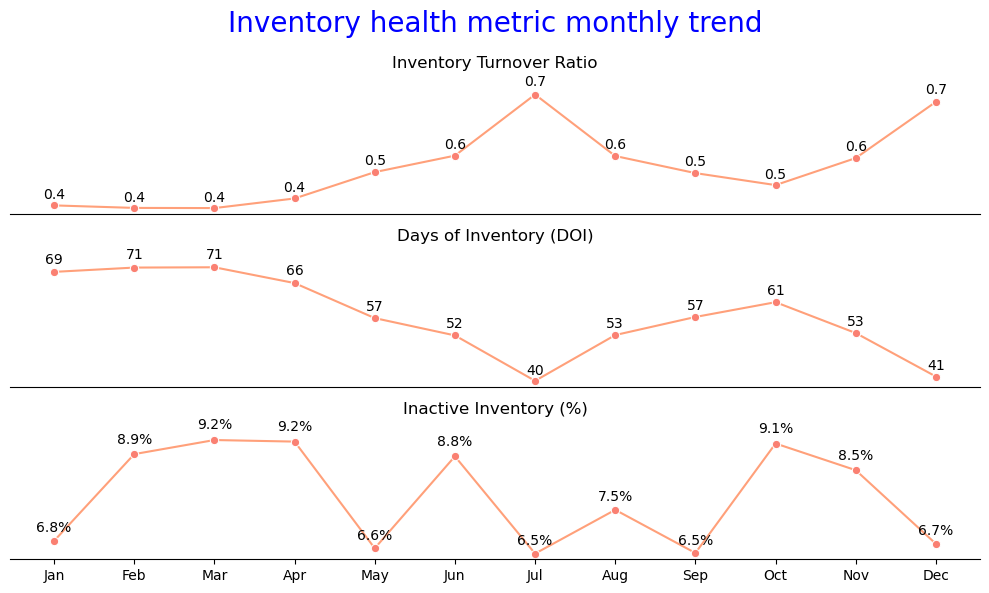

In [18]:
monthly_health = monthly_trend[['MonthName','InventoryTurnover','DOI','InactiveInv%']]

fig, ax = plt.subplots(3, 1, figsize=(10, 6))
cols = ['InventoryTurnover', 'DOI', 'InactiveInv%']
title_map = {'InventoryTurnover': 'Inventory Turnover Ratio',
                'DOI': 'Days of Inventory (DOI)',
                'InactiveInv%': 'Inactive Inventory (%)'}

for i, col in enumerate(cols):
    sns.lineplot(data=monthly_health, y=col, x='MonthName', ax=ax[i], color='lightsalmon',
                 marker='o', markerfacecolor='salmon')
    for j, val in enumerate(monthly_health[col]):
        # conditional formatting
        if col == 'InactiveInv%':
            label = f"{round(val, 1)}%"
        elif col == 'DOI':
            label = int(val)
        else:  # InventoryTurnover
            label = f"{round(val, 1)}"
        ax[i].text(j, val*1.02, label, ha='center', va='bottom')
    
    ax[i].set_title(title_map[col], fontsize=12, pad=15)
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')
    ax[i].set_yticks([])

    if i != 2:
        ax[i].set_xticks([])
sns.despine(left =True)
plt.suptitle('Inventory health metric monthly trend', color='blue', fontsize=20)
plt.tight_layout()
plt.show()

> - Inventory efficiency shows a clear mid year acceleration, with turnover rising and peaks in July and December, indicating faster stock movement during these periods. Days of Inventory (DOI) mirrors this trend inversely, improving in Jul and Dec indicating tighter inventory cycles and reduced holding duration.

> - Quarter 1(Jan–Mar) reflects relatively inefficient inventory movement, with consistently low turnover and highest DOI levels, indicating slower sell through during this period.

> - Inactive inventory %  remains volatile across months, peaking around March to April and October ,showing buildup of non moving stock despite improvements in turnover. No consistent alignment between turnover and inactive inventory %, as some high turnover months still show high inactive inventory, indicating uneven demand distribution across products.

> - The overall pattern is suggesting seasonality in inventory movement with stronger efficiency in mid year and year end periods, while early months experience slower inventory cycling and higher holding periods

#### Demand vs Inventory Alignment

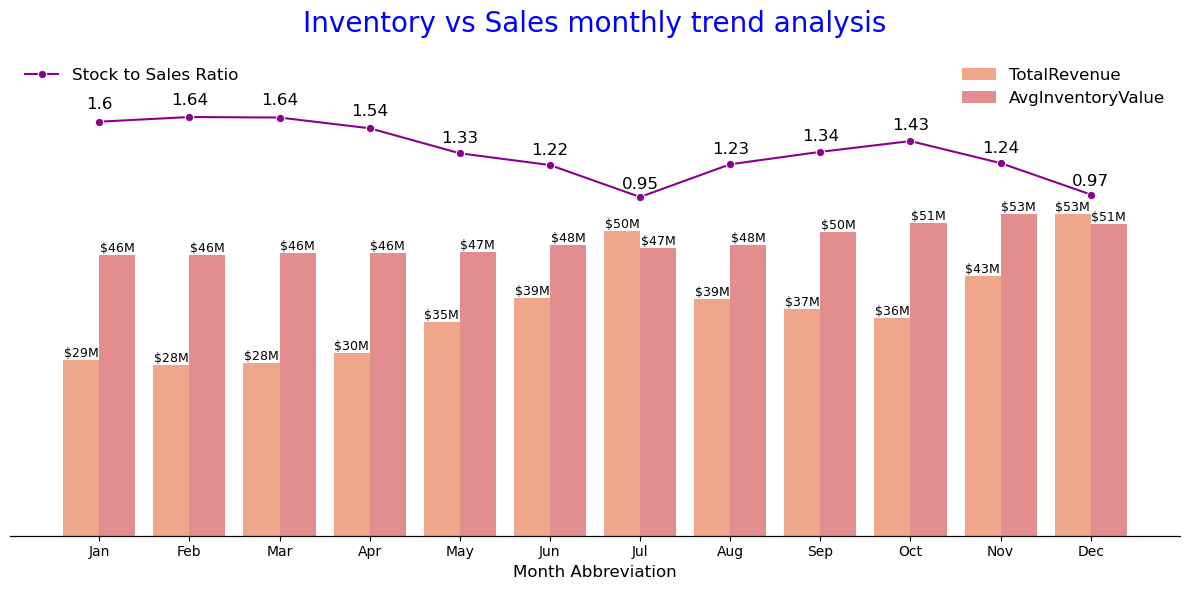

In [ ]:
# data to plot
df_plot = monthly_trend.melt(id_vars='MonthName',
                value_vars=['TotalRevenue', 'AvgInventoryValue'],
                var_name='Metric',value_name='Value')

plt.figure(figsize=(12,6))

ax = sns.barplot(data=df_plot,x='MonthName',y='Value',hue='Metric',palette=['lightsalmon', 'lightcoral'])
for container in ax.containers:
    for bar in container:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(),f'${int( bar.get_height()/1_000_000)}M',
                ha='center',va='bottom',fontsize=9)
ax.set_yticks([])
ax.set_ylabel('')
ax.set_ylim(0, df_plot['Value'].max() * 1.5)
ax.set_xlabel('Month Abbreviation', fontsize=12)
ax.legend(title='', frameon=False, fontsize=12)

ax2= ax.twinx()
sns.lineplot(data= monthly_trend, x='MonthName', y='StocktoSales',
             marker='o', color='darkmagenta', label='Stock to Sales Ratio',ax=ax2)
for i,txt in enumerate(monthly_trend['StocktoSales']):
    ax2.text(i,txt*1.05,round(txt,2), va='bottom',ha='center', fontsize=12)
ax2.set_ylabel('')
ax2.set_yticks([])
ax2.set_ylim(-2,2.2)
ax2.legend(title='',frameon=False,loc='upper left',fontsize=12)

plt.title("Inventory vs Sales monthly trend analysis",color='blue',fontsize=20,pad=15)
sns.despine(left=True)
plt.tight_layout()
plt.show()

> - For period Jan-Jun Average inventory remained consistent while revenue showed gradual growth, indicating balanced inventory planning aligned with steady demand.

> - Revenue increased sharply in July while inventory grew at a slower pace, such that strong sales absorbed excess inventory built up in previous months.

> - From Aug-Oct Revenue declined while average inventory increased significantly , indicating inventory buildup and slower movement of stock.

> - Revenue rebounded while inventory slightly reduced during Nov-Dec period, indicating improved inventory absorption and restored demand–supply balance.

> - Overall, inventory remained well aligned with the demand during growth phases but showed slow adjustment during demand slowdowns, leading to temporary overstocking before realignment at year end.

#### Inventory Concentration Analysis

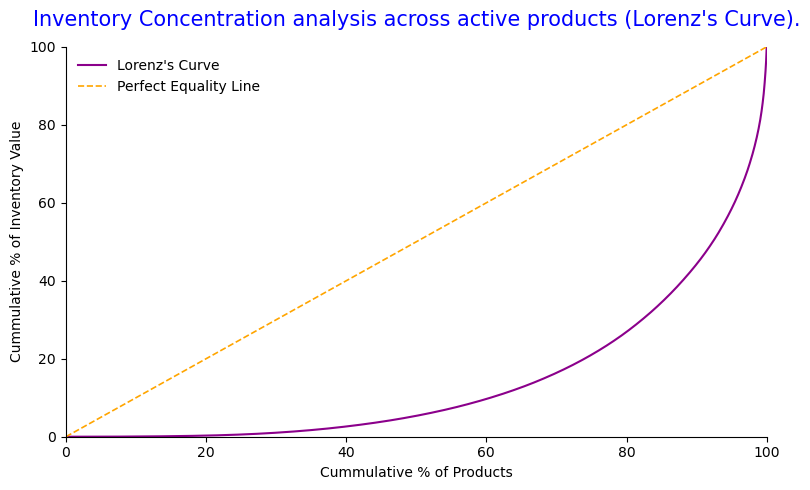

In [20]:
# filtering for only selling products
product_inventory = inv_snapshot[inv_snapshot['SalesQuantity']>0].groupby(
                        'ProductId')['AvgInventoryValue'].sum().dropna().sort_values()
product_inventory = product_inventory[product_inventory > 0].reset_index()

# ranking products in increasing order of inventory value
product_inventory['Rank'] = product_inventory.index+1

# Cummulative Ranking %
product_inventory['CumPercRank'] = product_inventory['Rank']/len(product_inventory)

# Cummulative Inventory Share %
product_inventory['CumInventoryPerc']=(product_inventory['AvgInventoryValue'].cumsum() /
                                        product_inventory['AvgInventoryValue'].sum())

plt.figure(figsize=(8,5))

ax = sns.lineplot(data= product_inventory, x='CumPercRank', y='CumInventoryPerc',
                 color='darkmagenta', label="Lorenz's Curve")
plt.plot([0, 1], [0, 1], label="Perfect Equality Line", color='orange', linestyle="--", linewidth=1.2)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: int(x*100)))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: int(x*100)))

plt.xlabel("Cummulative % of Products")
plt.ylabel("Cummulative % of Inventory Value")
plt.title("Inventory Concentration analysis across active products (Lorenz's Curve).",
           color='blue', fontsize=15,pad=15)
plt.legend(frameon=False)
plt.xlim(0,1)
plt.ylim(0,1)

sns.despine()
plt.tight_layout()
plt.show()

In [21]:
# Gini Coefficient Calculation
ginidf = product_inventory[['CumPercRank', 'CumInventoryPerc']].copy()
ginidf = pd.concat([pd.DataFrame({'CumPercRank':[0], 'CumInventoryPerc':[0]}),ginidf], ignore_index=True)

ginidf['x_prev'] = ginidf['CumPercRank'].shift(1)
ginidf['y_prev'] = ginidf['CumInventoryPerc'].shift(1)
ginidf = ginidf.dropna()

area= np.sum((ginidf['CumInventoryPerc'] + ginidf['y_prev']) * 
              (ginidf['CumPercRank'] - ginidf['x_prev']) / 2)
gini = 1- 2*area
print('Gini Coefficient Value :',round(gini,3))

top20_contri = (1- product_inventory[product_inventory['CumPercRank'] >= .80]['CumInventoryPerc'].min())*100
print(f"Top 20% active products by inventory contribute {top20_contri:.2f}% of the total inventory value.")

Gini Coefficient Value : 0.712
Top 20% active products by inventory contribute 73.10% of the total inventory value.


> - The Lorenz curve’s strong deviation from equality reflects significant skewness, where most products contribute minimally to inventory value while a few dominate stock holding. A Gini coefficient of 0.712 tells high inventory concentration and increasing sensitivity to demand fluctuations for those key products.

> - The distribution highlights structural imbalance in inventory allocation, where capital is disproportionately tied up in select products rather than evenly spread across the products.

#### Inventory Stability Analysis

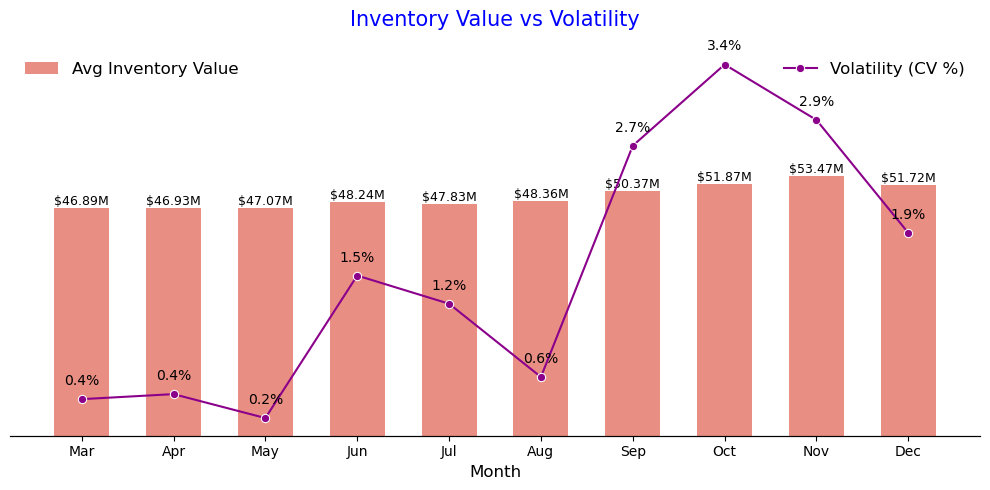

In [22]:
# Monthly Avg Inventory Capital
monthly_volatilty = monthly_trend[['MonthName','AvgInventoryValue']].copy()

# Rolling Standard Deviation (window = three months)
monthly_volatilty['RollingStd'] = monthly_volatilty['AvgInventoryValue'].rolling(window=3).std()

# Coefficient of variation (CV) = Rolling std dev/ Avg Inventory Capital
monthly_volatilty['CV']= monthly_volatilty['RollingStd']/monthly_volatilty['AvgInventoryValue']
monthly_volatilty = monthly_volatilty.dropna().reset_index(drop=True)

fig,ax1=plt.subplots(figsize=(10,5))

sns.barplot(data=monthly_volatilty,x='MonthName',y= 'AvgInventoryValue',ax=ax1,label='Avg Inventory Value',
            width=0.6,color='salmon')
for i,txt in enumerate(monthly_volatilty['AvgInventoryValue']):
    ax1.text(i,txt,format_currency(txt),ha='center',va='bottom',fontsize=9)
ax1.set_yticks([])
ax1.set_ylabel('')
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylim(0,monthly_volatilty['AvgInventoryValue'].max()*1.5)
ax1.legend(title='', frameon=False, fontsize=12,loc='upper left')

ax2 = ax1.twinx()
sns.lineplot(data=monthly_volatilty,x='MonthName',y='CV',ax=ax2,label='Volatility (CV %)',
             marker='o',color='darkmagenta')
for i,txt in enumerate(monthly_volatilty['CV']):
    ax2.text(i,txt+0.001,f'{round(txt*100,1)}%',ha='center',va='bottom',fontsize=10)
ax2.set_ylabel('')
ax2.set_yticks([])
ax2.legend(title='',frameon=False,fontsize=12)

plt.title('Inventory Value vs Volatility',color='blue',fontsize=15,pad=15)
sns.despine(left=True)
plt.tight_layout()
plt.show()

> - Inventory value steadily increases over time with the peak in November showing a gradual build up of stock across months rather than sudden changes.

> - Early months show very stable inventory levels with low CV of around 0.4% indicating minimal variation and consistent control over inventory.From June onwards variation in inventory starts increasing as CV rises up to 3.4% during October, showing that inventory levels become less consistent during this period.

> - Higher inventory levels in the later months are also more unstable meaning as stock increases it fluctuates more before showing some improvement again in December as CV falls to 1.9%.

#### Inventory Investment Distribution by Return (GMROI) 
GMROI : 
- if > 3 - High Return SKUs  
- 1 to 3 - Moderate Return SKUs   
- 0 to 1 - Low Return  
- < 0 - Negative Return

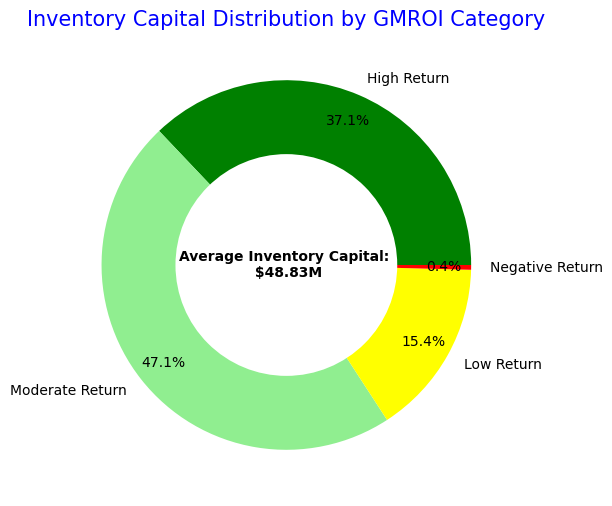

In [23]:
# Gross Profit and Avg Inventory Capital per SKU
product_gmroi = inv_snapshot.groupby('ProductId').agg({
                        'GrossProfit': 'sum',
                        'AvgInventoryValue': 'mean'}).reset_index()

# GMROI = Gross Profit/ Avg Inventory Cost
product_gmroi['GMROI'] = np.where(product_gmroi['AvgInventoryValue'] != 0,
                            product_gmroi['GrossProfit'] / product_gmroi['AvgInventoryValue'],0)

# Return Efficiency Segmentation
conditions = [product_gmroi['GMROI'] >= 3,
                (product_gmroi['GMROI'] >= 1) & (product_gmroi['GMROI'] < 3),
                (product_gmroi['GMROI'] >= 0) & (product_gmroi['GMROI'] < 1),
                product_gmroi['GMROI'] < 0]
labels = ['High Return','Moderate Return','Low Return','Negative Return']
product_gmroi['ROI_Category'] = np.select(conditions, labels, default='Unknown')

# Inventory Capital per ROI Category
category_summary = product_gmroi.groupby('ROI_Category')['AvgInventoryValue'].sum().reindex(labels).reset_index()
category_summary['Capital%'] = (category_summary['AvgInventoryValue'] *100/ 
                                category_summary['AvgInventoryValue'].sum())

# Pie chart
fig=plt.figure(figsize=(6,6))

colormap = {'High Return' : 'green', 'Moderate Return': 'lightgreen',
            'Low Return' : 'yellow','Negative Return': 'red'}
colors = category_summary['ROI_Category'].map(colormap)
plt.pie(category_summary['Capital%'],labels=category_summary['ROI_Category'],autopct='%1.1f%%',
        pctdistance=0.85,colors=colors)

fig.gca().add_artist(plt.Circle((0,0),0.6,fc='white'))
plt.text(0,0,f'Average Inventory Capital: \n {format_currency(category_summary['AvgInventoryValue'].sum())}', 
         fontweight='bold',ha='center',va='center')

plt.title('Inventory Capital Distribution by GMROI Category',color='blue', fontsize=15)
plt.show()

> - A majority of inventory capital is allocated to profitable segments (high + moderate return), indicating that most of the invested inventory is generating positive returns.
> - The moderate return segment holds the largest share, showing that a significant portion of capital is tied to products with decent but not optimal efficiency.
> - High return segment contributes around 37% of capital, reflecting a strong base of well performing products, though still smaller compared to moderate performers.
> - Low and negative return segments together account for around 16% of capital, highlighting that a noticeable portion of inventory is tied up in underperforming or loss making products.

#### Inventory and Revenue Distribution by Sales Velocity

In [24]:
product_velocity = inv_snapshot.groupby('ProductId',observed=False).agg({
                    'SalesQuantity' : 'sum',
                    'Revenue' : 'sum',
                    'AvgInventoryValue' : 'mean'}).sort_values(by='SalesQuantity',ascending=False).reset_index()

# Sales Velocity = Avg Units Sold per month
product_velocity['SalesVelocity'] = product_velocity['SalesQuantity']/12

# Segmentation based on sales velocity
product_velocity['VelocitySegment'] = pd.cut(product_velocity['SalesVelocity'], bins=[0,30,500,float('inf')],
                                        labels=['Slow Movers','Medium Movers','Fast Movers'],duplicates='drop')

segment_summary = product_velocity.groupby('VelocitySegment',observed=False).agg({
                    'ProductId' : 'count',
                    'Revenue' : 'sum',
                    'AvgInventoryValue' : 'sum'}).rename(
                        columns={'ProductId': 'ProductCount'}).sort_values(by='Revenue',ascending=False)

# % SKU ,Revenue, Inventory Capital Share per Category
segment_summary['ProductShare'] = segment_summary['ProductCount'] *100/ segment_summary['ProductCount'].sum()
segment_summary['RevenueShare'] = segment_summary['Revenue']*100 /segment_summary['Revenue'].sum()
segment_summary['InventoryShare']= segment_summary['AvgInventoryValue']*100/segment_summary['AvgInventoryValue'].sum()

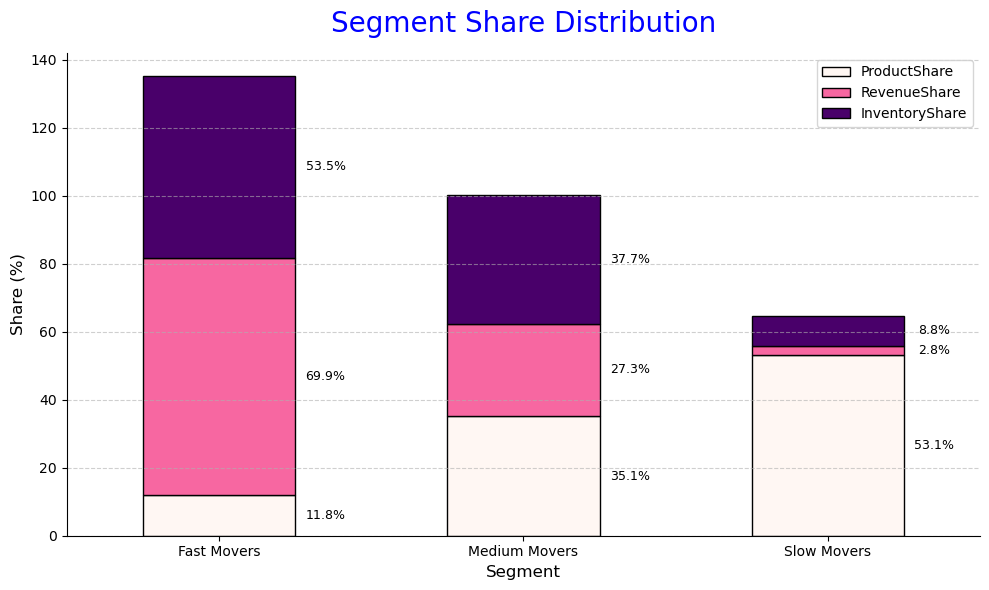

In [25]:
# Stacked bar chart
ax= segment_summary[['ProductShare','RevenueShare','InventoryShare']].plot(kind='bar',stacked=True,
                                    figsize=(10,6),colormap='RdPu',edgecolor='black')

for container in ax.containers:
    for bar in container:
        ax.text((bar.get_x()+bar.get_width())+0.1,bar.get_y()+bar.get_height()/2,f'{bar.get_height():.1f}%',
                ha='center',va='center',fontsize=9,color='black')

ax.set_title('Segment Share Distribution',fontsize=20,color='blue',pad=15)
ax.set_xlabel('Segment', fontsize=12)
ax.set_ylabel('Share (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=0)
sns.despine()
plt.tight_layout()
plt.show()

> - Fast moving products form a small portion of the catalog (around 12%) but drive the majority of revenue while also holding majority of inventory, showing strong demand concentration in a limited set of products.
> - Medium movers represent a balanced segment indicating steady but moderate contribution without extreme skew in either demand or stock allocation.
> - Slow moving products dominate the assortment (50% of products) but contribute very little to revenue despite holding 9% of inventory, highlighting a large long-tail of low-performing items
> - Overall, revenue is highly concentrated in fast movers while product count is concentrated in slow movers, indicating a clear mismatch between assortment size and actual demand distribution.

# Key Insights

#### 1. Inventory movement shows clear seasonal variation

- Inventory efficiency improves during mid year and year end periods, with higher turnover and lower DOI in July and December indicating faster stock movement, while in early months (Jan–Mar) show slower sell through and higher holding periods.
- Inactive inventory remains inconsistent across months, with periodic spikes (Mar–Apr, Oct) and no clear alignment with turnover, highlighting uneven demand across products.

#### 2. Demand and inventory alignment varies across periods

Inventory and demand remain well aligned during growth phases, with Jan–Jun showing stable inventory alongside gradual revenue increase and July reflecting strong sales absorbing existing stock. However, during Aug–Oct, inventory builds up while revenue declines, indicating slower stock movement and delayed adjustment to demand slowdown, before realignment is observed in Nov–Dec with improving sales and slight inventory correction.

#### 3. Inventory is highly concentrated across a limited set of products

Inventory distribution is heavily skewed, with a small set of products holding a large share of total inventory value as supported by high Gini coefficient value of 0.712. This indicates strong dependence on a few products and higher sensitivity to their demand fluctuations, while the broader product base contributes minimally, highlighting an imbalance in inventory allocation.

#### 4. Inventory levels increase over time with rising variability in later months

Inventory value shows a steady build up through the year peaking in November ,indicating gradual stock accumulation. Early months maintain high stability with very low variation (low CV), reflecting consistent control, while from June onwards variability increases, reaching highest levels around October. This shows that higher inventory levels in later months are also less stable, before partial stabilization is observed again in December.

#### 5. Majority of inventory capital is allocated to profitable segments

Most of the inventory investment is concentrated in high and moderate return segments, indicating that a large share of capital is generating positive returns. However, the moderate return segment holds the largest share, showing that a significant portion of capital is tied to products with average efficiency rather than top performers, while a smaller but notable share remains locked in low and negative return products, reflecting the presence of capital draining inventory.

#### 6. Revenue is highly concentrated among fast moving products while assortment is dominated by   slow movers

- Fast moving products represent a small share of the catalog but contribute the majority of revenue and hold a significant portion of inventory, showing strong demand concentration in a limited set of products.
- Medium movers maintain a balanced contribution across revenue and inventory, while slow moving products dominate the assortment but add minimal revenue despite holding some inventory showing a clear mismatch between product count and actual demand distribution.

---